In [1]:
import xarray as xr
import os   
import parflow as pf
import plotly.express as px
from parflow.tools.hydrology import calculate_overland_flow_grid, calculate_subsurface_storage, calculate_water_table_depth
import numpy as np
import shutil
import json
import plotly.io as pio

In [4]:
outlet_x = 66
outlet_y = 135

In [ ]:
root_dir = "/glade/derecho/scratch/bwest/drought-ensemble"
domain = "potomac_without_flow_barrier"
ensemble_name = "ensemble_1"
ensemble_member = "8_year_drought"
files = json.load(open(f"{root_dir}/domains/{domain}/processed_full_runs/{ensemble_name}/{ensemble_member}/file_locations_save.json"))
data = xr.open_mfdataset(files, concat_dim="time", combine="nested")
data.info()


/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/bwest/conda-envs/droughts/share/proj failed
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: 

xarray.Dataset {
dimensions:
	time = 196814 ;
	z = 10 ;
	y = 136 ;
	x = 70 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 subsurface_storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [ ]:
data['time'] = range(len(data.time))

In [ ]:

start = 8760
end = len(data.time)-(8760*5)

drought_streamflow = data["overland_flow"].isel(time=slice(8760, end, 24), x=outlet_x, y=outlet_y)


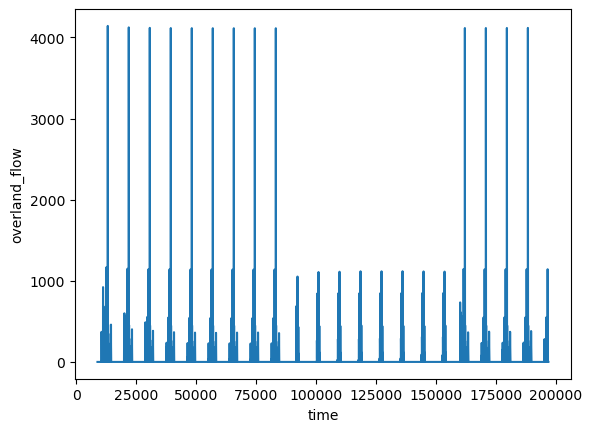

In [9]:
drought_streamflow.plot()